<a href="https://www.kaggle.com/code/aamir28/most-streamed-artists-on-spotify?scriptVersionId=339605829" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#121212 0%,#191414 100%); padding:44px 40px; border-radius:12px; border:1px solid #2A2A2A; font-family:'Circular','Helvetica Neue',Arial,sans-serif;">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <div style="width:32px; height:32px; border-radius:50%; background:#1DB954; display:flex; align-items:center; justify-content:center; font-size:16px;">▶</div>
    <span style="font-size:12px; font-weight:700; color:#B3B3B3; letter-spacing:1.5px; text-transform:uppercase;">Now Analyzing — Top 500 Chart</span>
  </div>

  <h1 style="margin:0 0 8px 0; font-size:36px; color:#FFFFFF; font-weight:800; letter-spacing:-0.5px;">
    Most Streamed Artists on Spotify
  </h1>
  <p style="margin:0 0 28px 0; font-size:15px; color:#B3B3B3;">
    500 artists, ranked by all-time total streams — snapshot dated July 17, 2026
  </p>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:2px; background:#2A2A2A; border-radius:8px; overflow:hidden;">
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#1DB954; font-size:22px; font-weight:800;">500</div>
      <div style="color:#B3B3B3; font-size:10.5px; margin-top:2px;">ARTISTS</div>
    </div>
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#1DB954; font-size:22px; font-weight:800;">137B</div>
      <div style="color:#B3B3B3; font-size:10.5px; margin-top:2px;">TOP ARTIST STREAMS</div>
    </div>
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#1DB954; font-size:22px; font-weight:800;">23</div>
      <div style="color:#B3B3B3; font-size:10.5px; margin-top:2px;">GENRES</div>
    </div>
    <div style="background:#181818; padding:16px; text-align:center;">
      <div style="color:#1DB954; font-size:22px; font-weight:800;">1939</div>
      <div style="color:#B3B3B3; font-size:10.5px; margin-top:2px;">EARLIEST DEBUT</div>
    </div>
  </div>

  <p style="margin:22px 0 0 0; font-size:12.5px; color:#727272;">
    Author: <b style="color:#FFFFFF;">Muhammad Aamir</b> &nbsp;|&nbsp; Focus: genre, geography, era &amp; solo-vs-collaborative streaming patterns
  </p>

</div>



<div style="background:#F5F5F5; border-left:4px solid #1DB954; border-radius:8px; padding:20px 26px; font-family:Arial,Helvetica,sans-serif; color:#191414;">
<h3 style="margin-top:0; font-weight:700; color:#1DB954; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Tracklist / Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#1DB954; text-decoration:none;">Setup &amp; Player Styling</a></li>
<li><a href="#firstlook" style="color:#1DB954; text-decoration:none;">First Look at the Chart</a></li>
<li><a href="#quality" style="color:#1DB954; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#top" style="color:#1DB954; text-decoration:none;">The Top of the Chart</a></li>
<li><a href="#demographics" style="color:#1DB954; text-decoration:none;">Who's on the Chart: Gender &amp; Artist Type</a></li>
<li><a href="#genre" style="color:#1DB954; text-decoration:none;">Genre Landscape</a></li>
<li><a href="#geo" style="color:#1DB954; text-decoration:none;">Where Artists Come From</a></li>
<li><a href="#era" style="color:#1DB954; text-decoration:none;">Career Eras: Debut Year vs. Streams</a></li>
<li><a href="#collab" style="color:#1DB954; text-decoration:none;">Solo vs. Collaborative Streaming</a></li>
<li><a href="#corr" style="color:#1DB954; text-decoration:none;">Correlation Check</a></li>
<li><a href="#dashboard" style="color:#1DB954; text-decoration:none;">Chart Dashboard</a></li>
<li><a href="#model" style="color:#1DB954; text-decoration:none;">Predicting Total Streams</a></li>
<li><a href="#conclusion" style="color:#1DB954; text-decoration:none;">Final Track</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">⚙️ 1. Setup &amp; Player Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Spotify Dark Player" palette ----
BG        = '#F5F5F5'
PANEL     = '#FFFFFF'
INK       = '#191414'
INK_SOFT  = '#727272'
GREEN     = '#1DB954'
BLACK     = '#191414'
PINK      = '#E91E63'
BLUE      = '#2E77D0'
AMBER     = '#E8A33D'
PURPLE    = '#8854D0'
GRID      = '#E0E0E0'

SEX_COLORS = {'Male': BLUE, 'Female': PINK, 'Mixed': PURPLE}
TYPE_COLORS = {'Solo': GREEN, 'Group': AMBER}
PALETTE_CAT = [GREEN, PINK, BLUE, AMBER, PURPLE, INK_SOFT]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Player styling loaded.")

Player styling loaded.


<h2 id="firstlook" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🎧 2. First Look at the Chart</h2>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/rishavsvault/most-streamed-artists-on-spotify/Most Streamed Artists on Spotify (17_07_2026) V1.1.csv')
df.columns = [c.strip() for c in df.columns]
print(f"Shape: {df.shape[0]} artists x {df.shape[1]} columns\n")
df.head(6)


Shape: 500 artists x 14 columns



,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970
5,Ariana Grande,Female,United States,English,Pop,Solo,2013,68298.9,57097.5,11201.4,41615.5,60.931435,26683.4,39.068565


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5   Artist Type                          500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

<h2 id="quality" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

# Two different partitions of total streams: solo/collaborative should sum exactly to total
solo_collab_diff = (df['Solo Streams (in millions)'] + df['Collaborative Streams (in millions)']
                     - df['Total Streams (in millions)']).abs()
print(f"\nSolo + Collaborative vs. Total — max discrepancy: {solo_collab_diff.max():.6f} (an exact partition)")

# Lead/Feature is a *different* partition (by songwriting/billing credit, not track type) so it needn't match exactly
lead_feature_diff = (df['Lead Streams (in millions)'] + df['Feature Streams (in millions)']
                      - df['Total Streams (in millions)']).abs()
print(f"Lead + Feature vs. Total — typical discrepancy: {lead_feature_diff.median():.1f}M (a different partition, not an error)")


Duplicate rows: 0
Missing values: 0

Solo + Collaborative vs. Total — max discrepancy: 0.000000 (an exact partition)
Lead + Feature vs. Total — typical discrepancy: 5.5M (a different partition, not an error)



<div style="background:#F5F5F5; border-left:3px solid #1DB954; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:6px;">
No missing values or duplicates. <b>Solo + Collaborative streams sum exactly to Total</b> — that's a clean track-type
split. <b>Lead + Feature streams don't sum exactly to Total</b>, but that's expected rather than a defect: it's a
different split (billing credit, not track type) — an artist can be the "lead" on a collaborative track, so the
two partitions overlap rather than mirror each other.
</div>


<h2 id="top" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🏆 4. The Top of the Chart</h2>

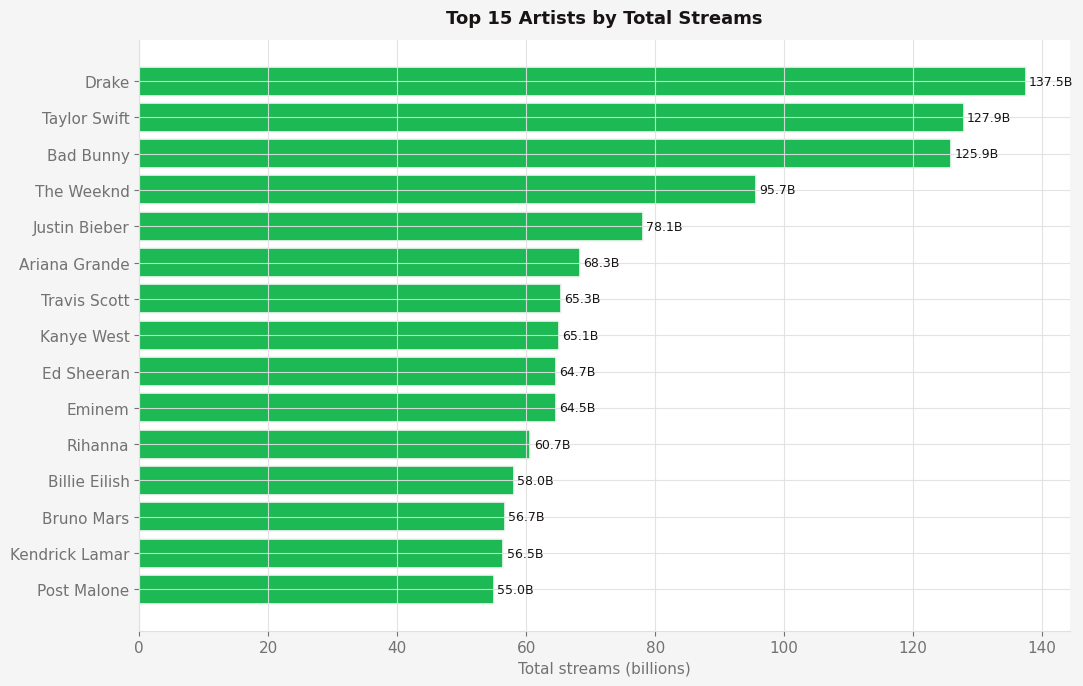

In [5]:

top15 = df.nlargest(15, 'Total Streams (in millions)')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15['Artist Name'][::-1], top15['Total Streams (in millions)'][::-1]/1000, color=GREEN, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.5, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}B", va='center', fontsize=9, color=INK)
style_ax(ax, 'Top 15 Artists by Total Streams', 'Total streams (billions)', '')
plt.tight_layout()
plt.show()


<h2 id="demographics" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🎤 5. Who's on the Chart: Gender &amp; Artist Type</h2>

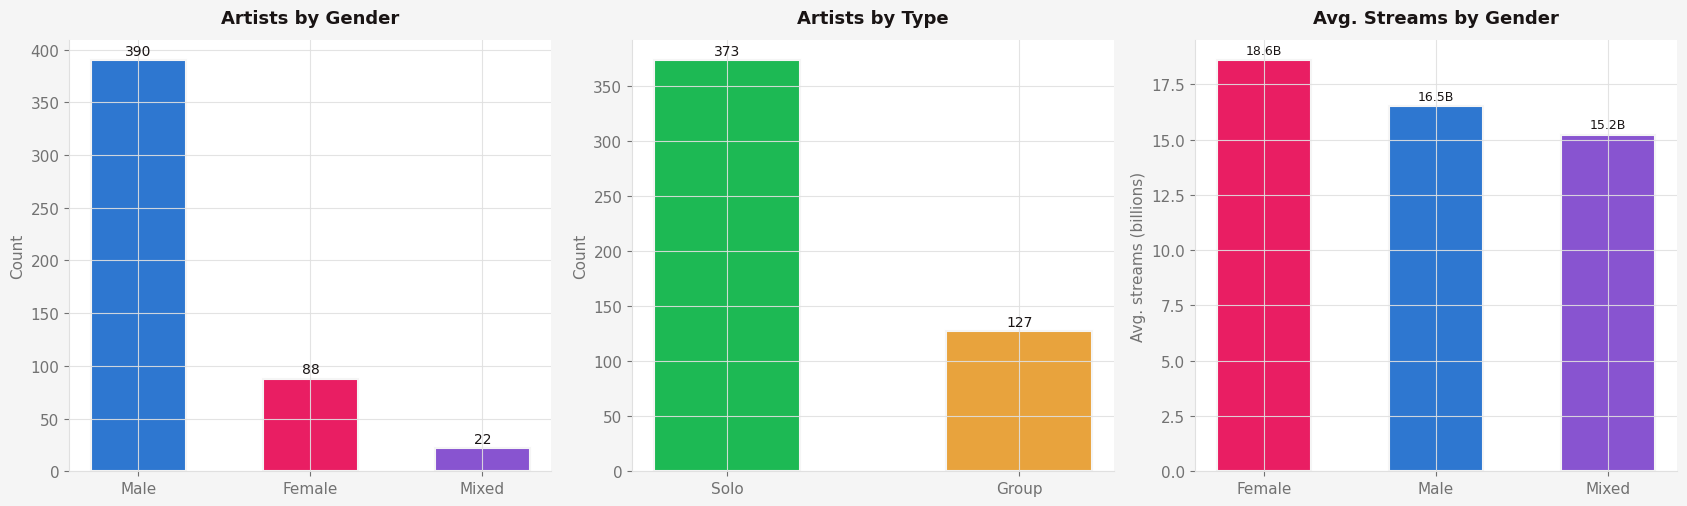

Male artists make up 78% of the top 500 — a well-documented gender gap
in mainstream streaming charts. Interestingly, average streams per artist run slightly higher for female
artists here, suggesting the gap is about how many chart rather than how much each one streams.


In [6]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

ax = axes[0]
sex_counts = df['Sex'].value_counts()
bars = ax.bar(sex_counts.index, sex_counts.values, color=[SEX_COLORS[s] for s in sex_counts.index], edgecolor=BG, linewidth=1.5, width=0.55)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Artists by Gender', '', 'Count')

ax = axes[1]
type_counts = df['Artist Type'].value_counts()
bars = ax.bar(type_counts.index, type_counts.values, color=[TYPE_COLORS[t] for t in type_counts.index], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, int(b.get_height()), ha='center', fontsize=10, color=INK)
style_ax(ax, 'Artists by Type', '', 'Count')

ax = axes[2]
sex_streams = df.groupby('Sex')['Total Streams (in millions)'].mean()/1000
bars = ax.bar(sex_streams.index, sex_streams.values, color=[SEX_COLORS[s] for s in sex_streams.index], edgecolor=BG, linewidth=1.5, width=0.55)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f"{b.get_height():.1f}B", ha='center', fontsize=9, color=INK)
style_ax(ax, 'Avg. Streams by Gender', '', 'Avg. streams (billions)')

plt.tight_layout()
plt.show()

print(f"Male artists make up {sex_counts['Male']/len(df)*100:.0f}% of the top 500 — a well-documented gender gap")
print("in mainstream streaming charts. Interestingly, average streams per artist run slightly higher for female")
print("artists here, suggesting the gap is about how many chart rather than how much each one streams.")


<h2 id="genre" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🎶 6. Genre Landscape</h2>

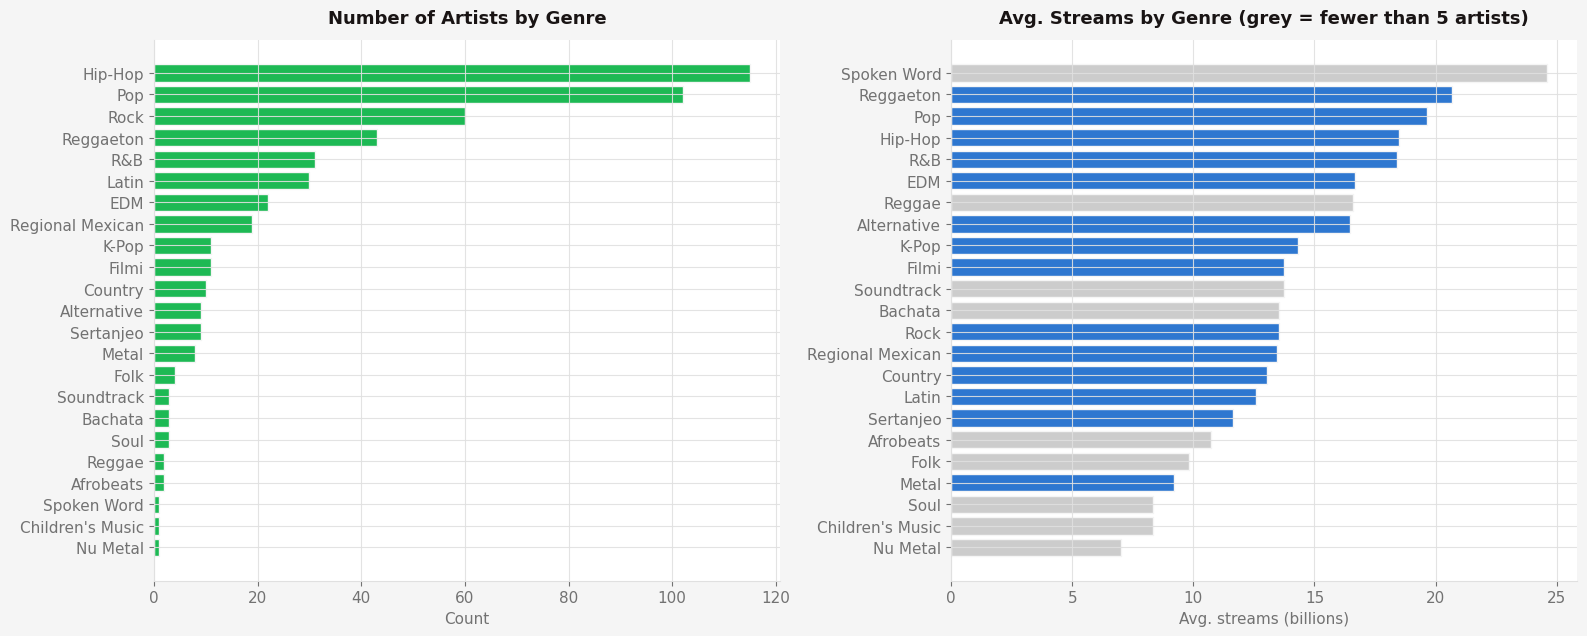

Hip-Hop and Pop dominate by artist count. Several genres at the top of the 'avg. streams' chart (Spoken
Word, Children's Music, Soundtrack) are represented by only 1-3 artists — read those averages as single
data points, not a genre-wide pattern.


In [7]:

genre_counts = df['Primary Genre'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

ax = axes[0]
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color=GREEN, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Number of Artists by Genre', 'Count', '')

ax = axes[1]
genre_streams = df.groupby('Primary Genre')['Total Streams (in millions)'].mean().sort_values()
colors = ['#CCCCCC' if genre_counts[g] < 5 else BLUE for g in genre_streams.index]
bars = ax.barh(genre_streams.index, genre_streams.values/1000, color=colors, edgecolor=BG, linewidth=1.0)
style_ax(ax, 'Avg. Streams by Genre (grey = fewer than 5 artists)', 'Avg. streams (billions)', '')

plt.tight_layout()
plt.show()

print("Hip-Hop and Pop dominate by artist count. Several genres at the top of the 'avg. streams' chart (Spoken")
print("Word, Children's Music, Soundtrack) are represented by only 1-3 artists — read those averages as single")
print("data points, not a genre-wide pattern.")


<h2 id="geo" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🌍 7. Where Artists Come From</h2>

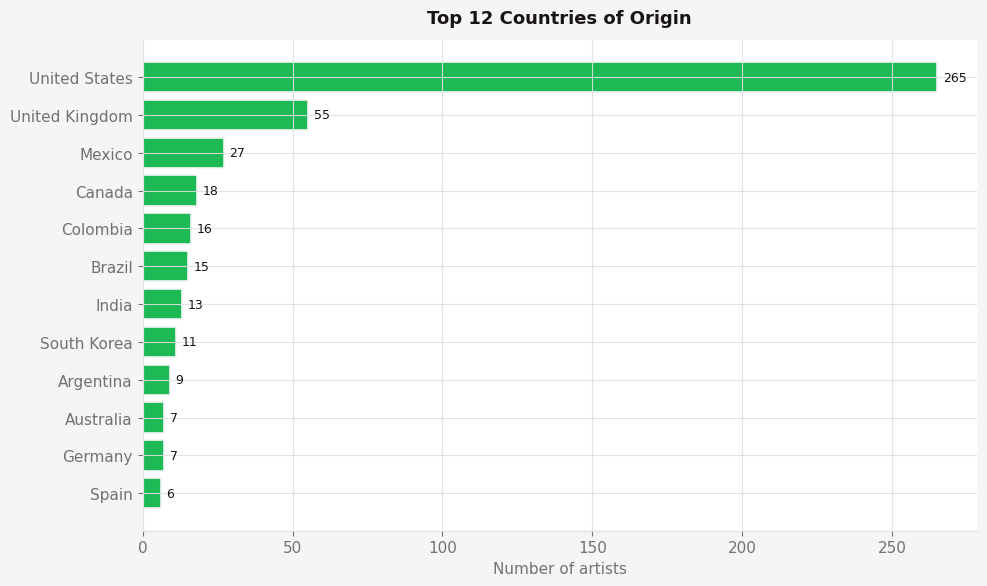

The United States accounts for 53% of the top 500 on its own —
with the UK, Mexico, and a strong Latin American showing (Colombia, Brazil, Argentina) rounding out the top ranks.


In [8]:

country_counts = df['Country of Origin'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_counts.index[::-1], country_counts.values[::-1], color=GREEN, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+2, b.get_y()+b.get_height()/2, int(b.get_width()), va='center', fontsize=9, color=INK)
style_ax(ax, 'Top 12 Countries of Origin', 'Number of artists', '')
plt.tight_layout()
plt.show()

print(f"The United States accounts for {country_counts.iloc[0]/len(df)*100:.0f}% of the top 500 on its own —")
print("with the UK, Mexico, and a strong Latin American showing (Colombia, Brazil, Argentina) rounding out the top ranks.")


<h2 id="era" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">📅 8. Career Eras: Debut Year vs. Streams</h2>

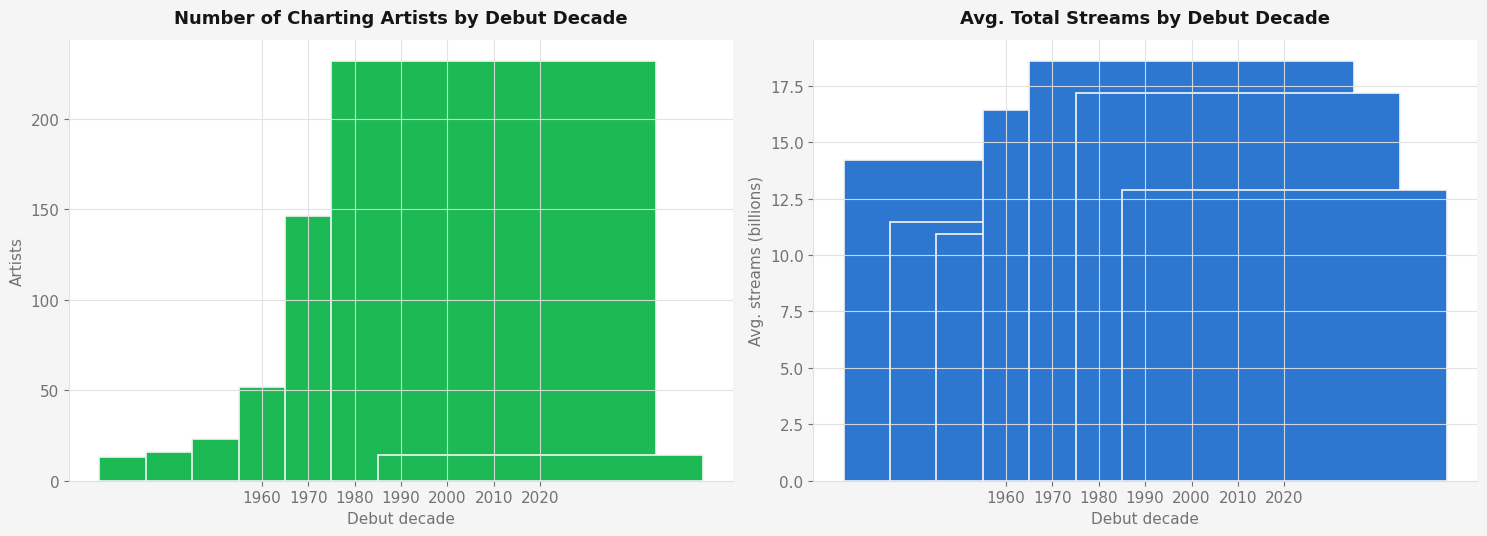

The 2000s and 2010s dominate both artist count and average streams — the era when today's streaming-native
superstars debuted, though a handful of legacy acts (Sinatra, Elvis, The Beatles) still chart from decades earlier.


In [9]:

df['decade'] = (df['Debut Year']//10)*10
decade_stats = df.groupby('decade').agg(avg_streams=('Total Streams (in millions)','mean'), n=('Artist Name','size'))
decade_stats = decade_stats[decade_stats['n'] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
bars = ax.bar(decade_stats.index.astype(str), decade_stats['n'], color=GREEN, edgecolor=BG, linewidth=1.2, width=7)
style_ax(ax, 'Number of Charting Artists by Debut Decade', 'Debut decade', 'Artists')

ax = axes[1]
bars = ax.bar(decade_stats.index.astype(str), decade_stats['avg_streams']/1000, color=BLUE, edgecolor=BG, linewidth=1.2, width=7)
style_ax(ax, 'Avg. Total Streams by Debut Decade', 'Debut decade', 'Avg. streams (billions)')

plt.tight_layout()
plt.show()

print("The 2000s and 2010s dominate both artist count and average streams — the era when today's streaming-native")
print("superstars debuted, though a handful of legacy acts (Sinatra, Elvis, The Beatles) still chart from decades earlier.")


<h2 id="collab" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🤝 9. Solo vs. Collaborative Streaming</h2>

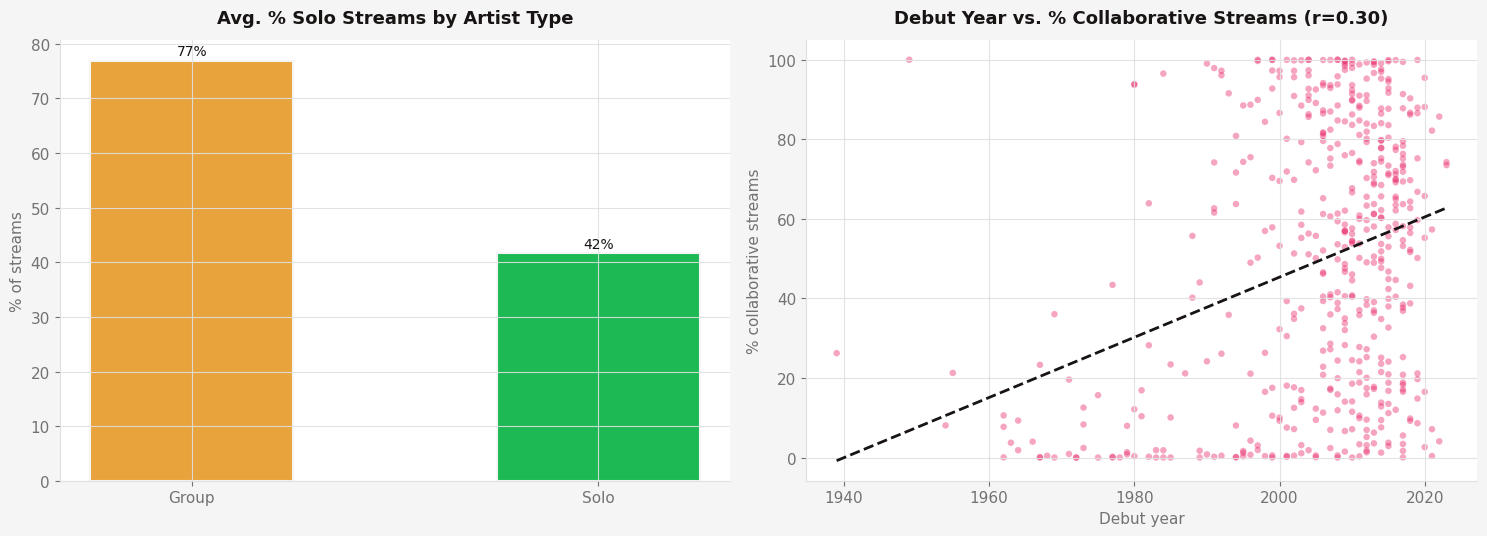

Group acts lean far more 'solo-track' by definition (the whole group performing together counts as solo),
while later-debuting artists trend toward a higher share of collaborative streams — consistent with the
real-world rise of the feature-heavy, playlist-driven streaming era.


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
type_solo = df.groupby('Artist Type')['% of Solo Streams'].mean()
bars = ax.bar(type_solo.index, type_solo.values, color=[TYPE_COLORS[t] for t in type_solo.index], edgecolor=BG, linewidth=1.5, width=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{b.get_height():.0f}%", ha='center', fontsize=10, color=INK)
style_ax(ax, 'Avg. % Solo Streams by Artist Type', '', '% of streams')

ax = axes[1]
sample = df
ax.scatter(sample['Debut Year'], sample['% of Collaborative Streams'], alpha=0.4, s=22, color=PINK, edgecolor='none')
z = np.polyfit(df['Debut Year'], df['% of Collaborative Streams'], 1)
xline = np.linspace(df['Debut Year'].min(), df['Debut Year'].max(), 50)
ax.plot(xline, np.poly1d(z)(xline), color=INK, linewidth=2, linestyle='--')
r = df['Debut Year'].corr(df['% of Collaborative Streams'])
style_ax(ax, f'Debut Year vs. % Collaborative Streams (r={r:.2f})', 'Debut year', '% collaborative streams')

plt.tight_layout()
plt.show()

print("Group acts lean far more 'solo-track' by definition (the whole group performing together counts as solo),")
print("while later-debuting artists trend toward a higher share of collaborative streams — consistent with the")
print("real-world rise of the feature-heavy, playlist-driven streaming era.")


<h2 id="corr" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🔗 10. Correlation Check</h2>

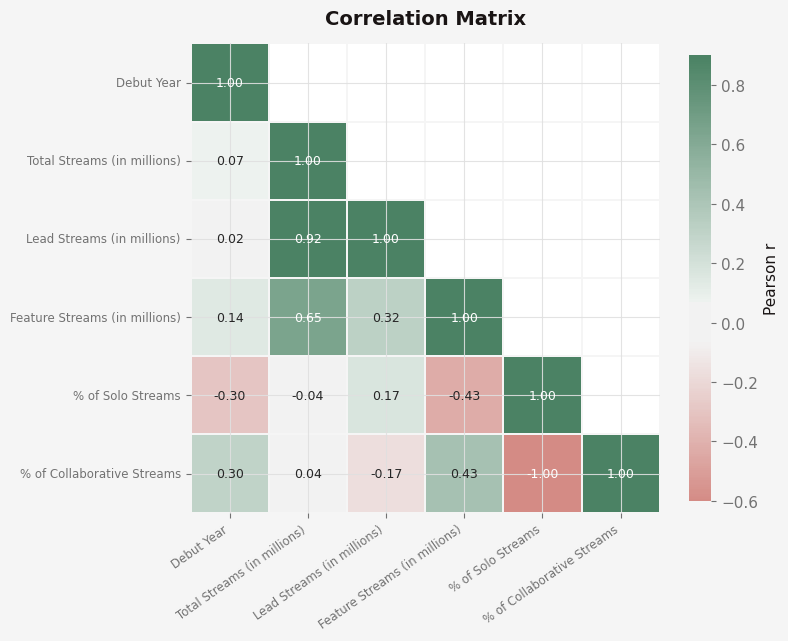

In [11]:

num_cols = ['Debut Year','Total Streams (in millions)','Lead Streams (in millions)',
            'Feature Streams (in millions)','% of Solo Streams','% of Collaborative Streams']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
cmap = sns.diverging_palette(15, 145, s=60, l=50, sep=20, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0, vmin=-0.6, vmax=0.9,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':9}, ax=ax)
ax.set_title('Correlation Matrix', color=INK, pad=14)
plt.xticks(rotation=35, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()


<h2 id="dashboard" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">📊 11. Chart Dashboard</h2>

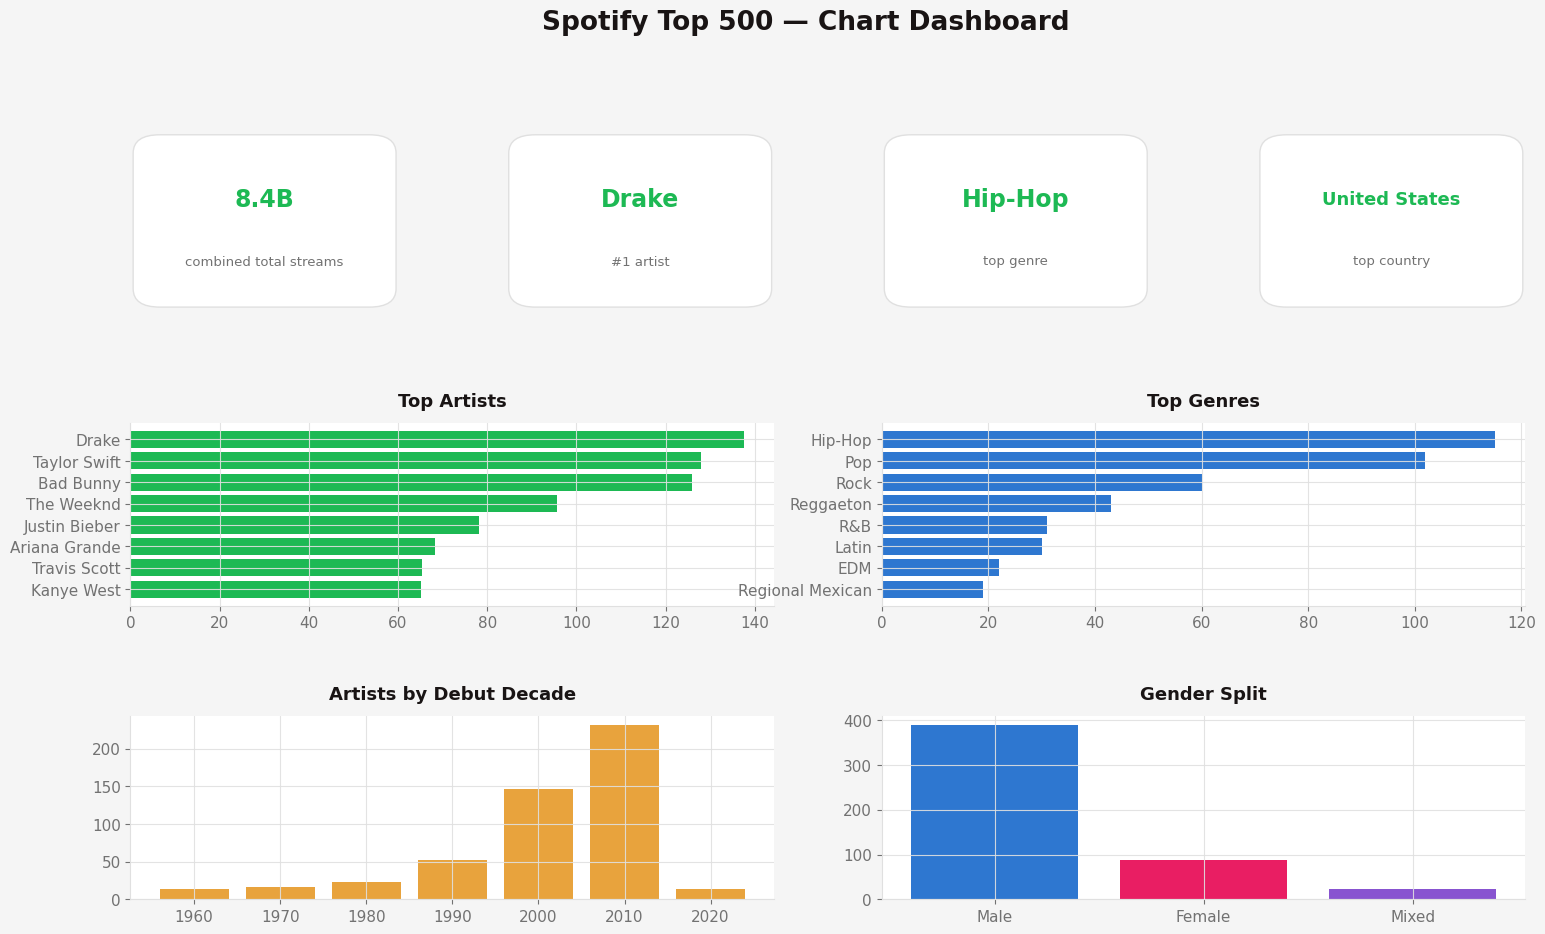

In [12]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('Spotify Top 500 — Chart Dashboard', fontsize=19, color=BLACK, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df['Total Streams (in millions)'].sum()/1e6:.1f}B", "combined total streams"),
    (df.loc[df['Total Streams (in millions)'].idxmax(),'Artist Name'], "#1 artist"),
    (f"{genre_counts.index[0]}", "top genre"),
    (f"{country_counts.index[0]}", "top country"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.10",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=17 if len(str(val))<12 else 13, color=GREEN, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.28, lab, ha='center', va='center', fontsize=9.5, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
bars = ax.barh(top15['Artist Name'][:8][::-1], top15['Total Streams (in millions)'][:8][::-1]/1000, color=GREEN)
style_ax(ax, 'Top Artists', '', '')

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(genre_counts.head(8).index[::-1], genre_counts.head(8).values[::-1], color=BLUE)
style_ax(ax, 'Top Genres', '', '')

ax = fig.add_subplot(gs[2, :2])
bars = ax.bar(decade_stats.index.astype(str), decade_stats['n'], color=AMBER)
style_ax(ax, 'Artists by Debut Decade', '', '')

ax = fig.add_subplot(gs[2, 2:])
bars = ax.bar(sex_counts.index, sex_counts.values, color=[SEX_COLORS[s] for s in sex_counts.index])
style_ax(ax, 'Gender Split', '', '')

plt.show()


<h2 id="model" style="font-family:Arial,Helvetica,sans-serif; color:#FFFFFF; background:#191414; padding:12px 18px; border-radius:8px;">🤖 12. Predicting Total Streams</h2>

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.copy()
cat_cols = ['Sex','Country of Origin','Primary Language','Primary Genre','Artist Type']
for c in cat_cols:
    model_df[c] = LabelEncoder().fit_transform(model_df[c])

features = ['Sex','Country of Origin','Primary Language','Primary Genre','Artist Type','Debut Year',
            '% of Solo Streams','% of Collaborative Streams']
X = model_df[features]
y = model_df['Total Streams (in millions)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.08, random_state=42, n_jobs=-1)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² = {r2:.3f} | MAE = {mae:,.0f}M streams")


Train: 400 rows | Test: 100 rows
Random Forest: R² = 0.124 | MAE = 10,741M streams
XGBoost: R² = 0.094 | MAE = 11,341M streams


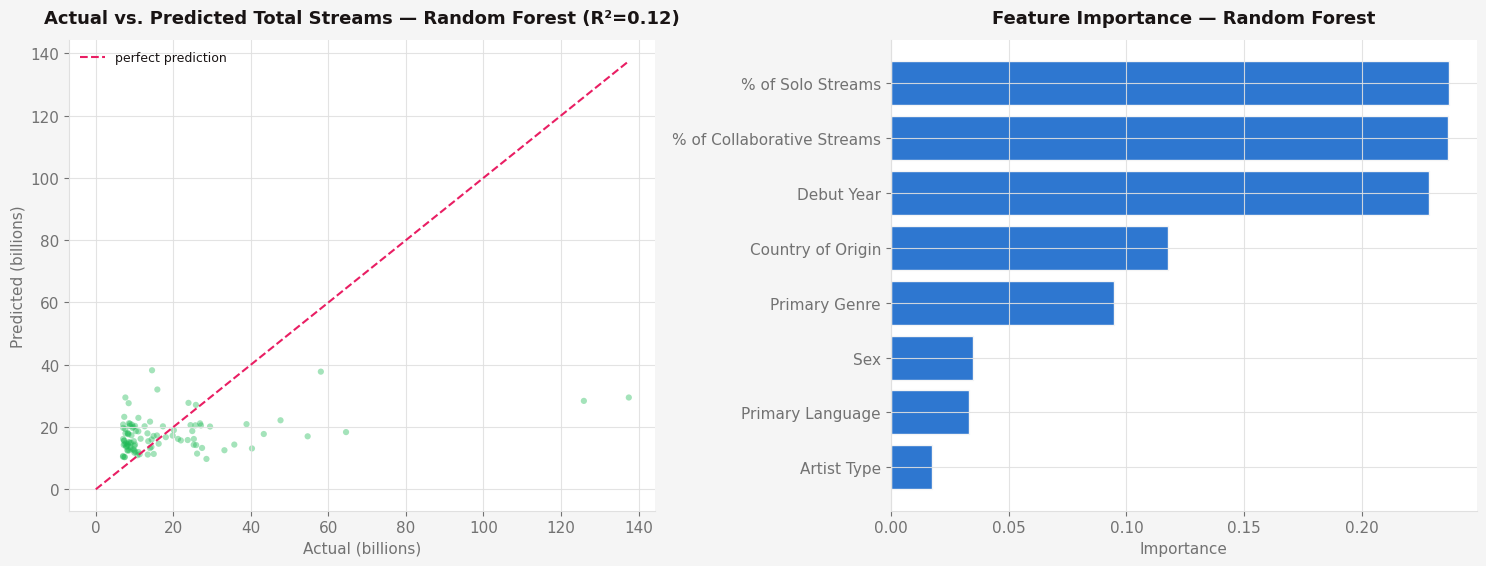

In [14]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test/1000, best['pred']/1000, alpha=0.4, s=20, color=GREEN, edgecolor='none')
lims = [0, max(y_test.max(), best['pred'].max())/1000]
ax.plot(lims, lims, color=PINK, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted Total Streams — {best_name} (R²={best["r2"]:.2f})', 'Actual (billions)', 'Predicted (billions)')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
importances = pd.Series(best['model'].feature_importances_, index=features).sort_values()
ax.barh(importances.index, importances.values, color=BLUE, edgecolor=BG)
style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F5F5F5; border-left:3px solid #1DB954; padding:14px 20px; font-family:Arial,Helvetica,sans-serif; color:#333; font-size:14px; border-radius:6px;">
The model reaches a moderate R² — meaningfully better than guessing, but far from perfect, which is exactly what
we'd expect for real streaming data. Total streams depend heavily on song quality, marketing, playlist placement
and cultural moment — factors this dataset simply doesn't capture. Debut year and the solo/collaborative streaming
split carry the most weight among available features, but a huge share of what makes an artist a top-500 act
isn't something demographics and genre alone can explain.
</div>



<div style="background:linear-gradient(135deg,#121212 0%,#191414 100%); padding:36px 40px; border-radius:12px; border:1px solid #2A2A2A; font-family:Arial,Helvetica,sans-serif; color:#FFFFFF;">

<h2 id="conclusion" style="margin-top:0; font-weight:800; color:#1DB954; border-bottom:2px solid #2A2A2A; padding-bottom:10px;">🎵 13. Final Track</h2>

<h4 style="color:#1DB954; font-weight:700; margin-bottom:6px;">What the chart shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DDDDDD;">
<li>Drake, Taylor Swift, and Bad Bunny lead the top 500 by total streams — a top tier that lines up with well-known real-world streaming leaderboards.</li>
<li>Male artists make up the large majority of the chart by count, but average streams per artist run slightly higher among female artists — the gender gap here is more about how many chart than how much each one streams.</li>
<li>Hip-Hop and Pop dominate by artist count; a handful of top-averaging genres (Spoken Word, Children's Music, Soundtrack) are single- or few-artist categories and shouldn't be read as genre-wide patterns.</li>
<li>The United States accounts for roughly half the chart, with a strong Latin American and UK presence rounding out the geography.</li>
<li>Later-debuting artists trend toward a higher share of collaborative streams — consistent with the real-world rise of feature-heavy, playlist-driven streaming.</li>
</ul>

<h4 style="color:#1DB954; font-weight:700; margin-bottom:6px;">Handled carefully</h4>
<p style="font-size:14.5px; color:#DDDDDD; line-height:1.8;">
Solo + Collaborative streams sum exactly to Total (a clean track-type split), while Lead + Feature streams don't —
that's expected, since it's a different partition (billing credit rather than track type), not a data error.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#727272; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
